# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the Adult Income Dataset and understand the characteristics of the data before preprocessing and model development.

## Analysis Performed

### 1. Target Variable Analysis

* Examined the distribution of income classes (`<=50K` and `>50K`).
* Evaluated class balance and target variable proportions.

### 2. Univariate Analysis

#### Numerical Features

The following numerical variables were analyzed using summary statistics, histograms, and boxplots:

* Age
* fnlwgt
* Education Number (`education_num`)
* Capital Gain (`capital_gain`)
* Capital Loss (`capital_loss`)
* Hours Per Week (`hours_per_week`)

#### Categorical Features

The following categorical variables were analyzed using frequency distributions and count plots:

* Workclass
* Occupation
* Education
* Marital Status
* Relationship
* Race
* Sex

### 3. Bivariate Analysis

The relationship between income and key features was explored using grouped statistics and visualizations:

* Education vs Income
* Hours Worked vs Income
* Age vs Income
* Occupation vs Income
* Marital Status vs Income
* Sex vs Income
* Race vs Income

### 4. Correlation Analysis

* Examined correlations among numerical features using a correlation matrix and heatmap.
* Assessed potential multicollinearity between variables.

## Outcome

The insights obtained from this analysis help identify important predictors of income, understand data distributions, detect imbalances, and establish a foundation for preprocessing, feature engineering, and predictive modeling in subsequent notebooks.


# **Data Loading**

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
columns = [
    'age','workclass','fnlwgt','education',
    'education_num','marital_status',
    'occupation','relationship','race',
    'sex','capital_gain','capital_loss',
    'hours_per_week','native_country',
    'income'
]
adult_data = pd.read_csv(
    "adult.data",
    header=None,
    names=columns,
    skipinitialspace=True
)
adult_test = pd.read_csv(
    "adult.test",
    header=None,
    names=columns,
    skiprows=1,
    skipinitialspace=True
)

## Dataset Overview

The Adult Census Income dataset contains demographic, educational, occupational, and financial attributes of individuals.

Training Dataset:
- 32,561 records
- 15 columns

Test Dataset:
- 16,281 records
- 15 columns

The dataset contains a mix of numerical and categorical features and is used to predict whether an individual's annual income exceeds $50K.

In [112]:
adult_data.shape

(32561, 15)

In [113]:
adult_test.shape

(16281, 15)

In [114]:
adult_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [115]:
adult_test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.


In [116]:
adult_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [117]:
adult_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16281 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             16281 non-null  int64 
 1   workclass       16281 non-null  object
 2   fnlwgt          16281 non-null  int64 
 3   education       16281 non-null  object
 4   education_num   16281 non-null  int64 
 5   marital_status  16281 non-null  object
 6   occupation      16281 non-null  object
 7   relationship    16281 non-null  object
 8   race            16281 non-null  object
 9   sex             16281 non-null  object
 10  capital_gain    16281 non-null  int64 
 11  capital_loss    16281 non-null  int64 
 12  hours_per_week  16281 non-null  int64 
 13  native_country  16281 non-null  object
 14  income          16281 non-null  object
dtypes: int64(6), object(9)
memory usage: 1.9+ MB


### **Target Variable Analysis**

#Income

The target variable is moderately imbalanced.

- Approximately 76% of individuals earn <=50K.
- Approximately 24% of individuals earn >50K.

Although the dataset is imbalanced, the minority class is sufficiently represented for model training and evaluation.

In [118]:
income_dist_train = pd.DataFrame({
    'Count': adult_data['income'].value_counts(),
    'Percentage': round(
        adult_data['income'].value_counts(normalize=True) * 100,
        2
    )
})
income_dist_train

,Count,Percentage
income,,
<=50K,24720,75.92
>50K,7841,24.08


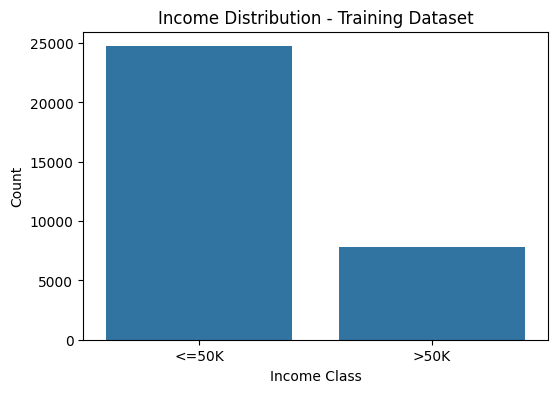

In [119]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=adult_data,
    x='income'
)
plt.title("Income Distribution - Training Dataset")
plt.xlabel("Income Class")
plt.ylabel("Count")
plt.show()

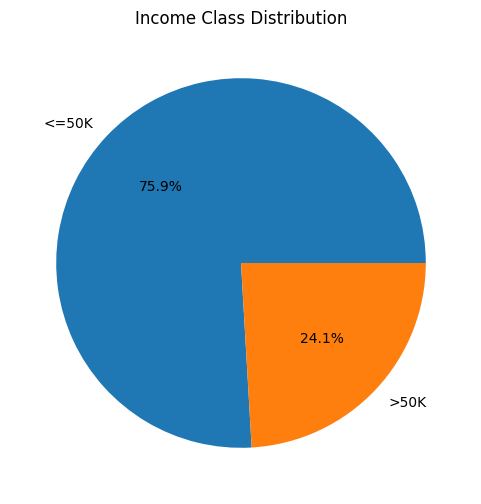

In [120]:
adult_data['income'].value_counts(normalize=True).plot(kind='pie',autopct='%1.1f%%',figsize=(6,6))
plt.title("Income Class Distribution")
plt.ylabel("")
plt.show()

# **Numerical Univariate Analysis**

### Age Feature Insights

- The age distribution is positively skewed.
- Most individuals fall between 25 and 50 years of age.
- The highest concentration of observations occurs around 30–35 years.
- Several observations above 75 years are identified as statistical outliers.
- These outliers appear to be legitimate observations rather than data entry errors.

In [121]:
adult_data['age'].describe()

,age
count,32561.000000
mean,38.581647
std,13.640433
min,17.000000
25%,28.000000
50%,37.000000
75%,48.000000
max,90.000000


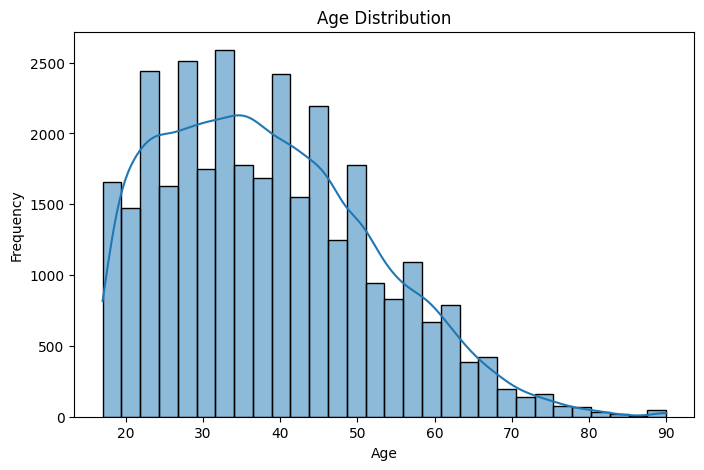

In [122]:
plt.figure(figsize=(8,5))
sns.histplot(
    adult_data['age'],
    bins=30,
    kde=True
)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

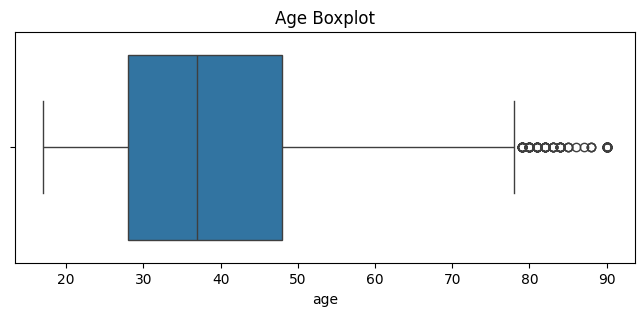

In [123]:
plt.figure(figsize=(8,3))
sns.boxplot(
    x=adult_data['age']
)
plt.title('Age Boxplot')
plt.show()

### Education Number Insights

- The education_num feature exhibits a discrete distribution with noticeable peaks around values 9, 10, and 13.
- Most individuals possess education levels between 9 and 12.
- Lower education levels (1–4) appear as statistical outliers but represent valid observations.
- The feature is expected to be strongly associated with income and will be investigated further through bivariate analysis.

In [124]:
adult_data['education_num'].describe()

,education_num
count,32561.000000
mean,10.080679
std,2.572720
min,1.000000
25%,9.000000
50%,10.000000
75%,12.000000
max,16.000000


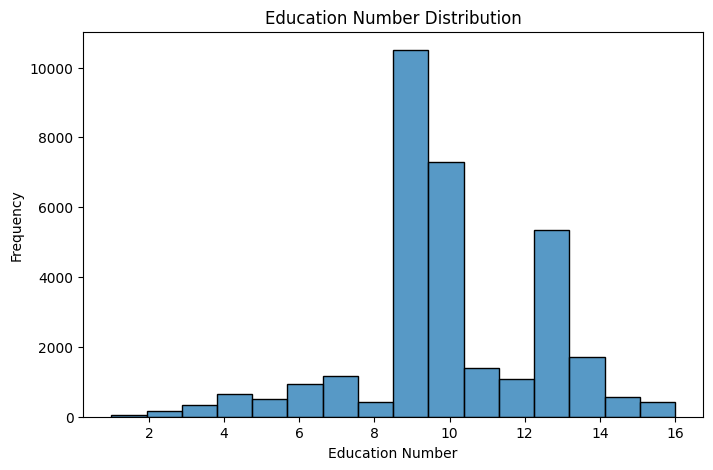

In [125]:
plt.figure(figsize=(8,5))
sns.histplot(
    adult_data['education_num'],
    bins=16
)
plt.title('Education Number Distribution')
plt.xlabel('Education Number')
plt.ylabel('Frequency')
plt.show()

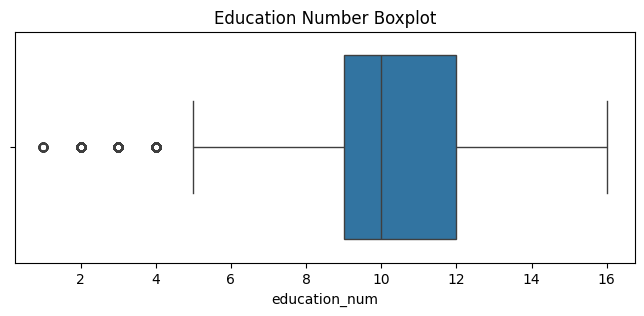

In [126]:
plt.figure(figsize=(8,3))
sns.boxplot(
    x=adult_data['education_num']
)
plt.title('Education Number Boxplot')
plt.show()

In [127]:
adult_data['education_num'].value_counts().sort_index()

,count
education_num,
1,51
2,168
3,333
4,646
5,514
6,933
7,1175
8,433
9,10501


### Hours Per Week Insights

- The distribution of hours worked per week is concentrated around 40 hours, indicating that a standard full-time work schedule is common among individuals in the dataset.
- The median number of hours worked per week is 40 hours.
- The feature exhibits a right-skewed distribution, with a subset of individuals working significantly more than the typical work week.
- Several observations above 60 hours per week are identified as statistical outliers.
- These outliers represent valid working patterns rather than data quality issues and should not be removed solely based on their values.
- The minimum recorded working time is 1 hour per week, while the maximum is 99 hours per week.
- The presence of individuals working substantially more hours than average suggests potential variation in employment type, occupation, or income level.

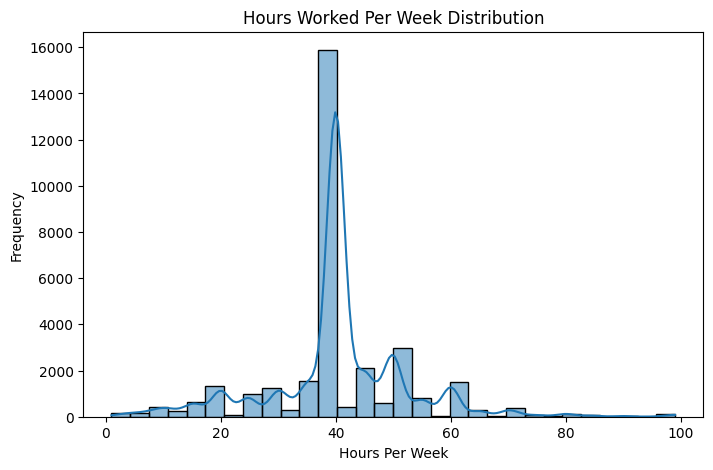

In [128]:
plt.figure(figsize=(8,5))
sns.histplot(
    adult_data['hours_per_week'],
    bins=30,
    kde=True
)
plt.title('Hours Worked Per Week Distribution')
plt.xlabel('Hours Per Week')
plt.ylabel('Frequency')

plt.show()

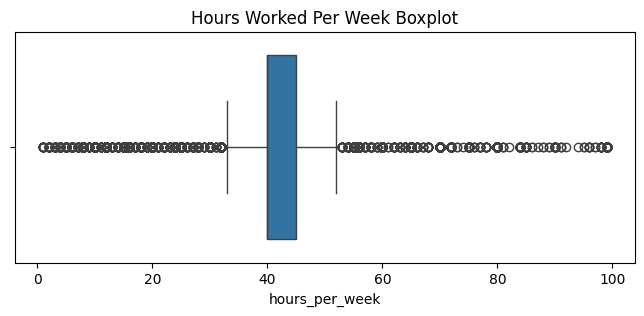

In [129]:
plt.figure(figsize=(8,3))
sns.boxplot(
    x=adult_data['hours_per_week']
)
plt.title('Hours Worked Per Week Boxplot')
plt.show()

In [130]:
adult_data['hours_per_week'].describe()

,hours_per_week
count,32561.000000
mean,40.437456
std,12.347429
min,1.000000
25%,40.000000
50%,40.000000
75%,45.000000
max,99.000000


### Capital Gain Insights

- The capital_gain feature exhibits an extremely right-skewed distribution.
- More than 75% of individuals have a capital gain value of zero.
- A small number of individuals report very large capital gains, resulting in a maximum value of 99,999.
- The mean capital gain is substantially higher than the median, indicating the presence of extreme high-value observations.
- Numerous statistical outliers are visible in the boxplot; however, these represent valid observations rather than data quality issues.
- The feature may provide valuable predictive information because large capital gains are typically associated with higher-income individuals.

In [131]:
adult_data['capital_gain'].describe()

,capital_gain
count,32561.000000
mean,1077.648844
std,7385.292085
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000


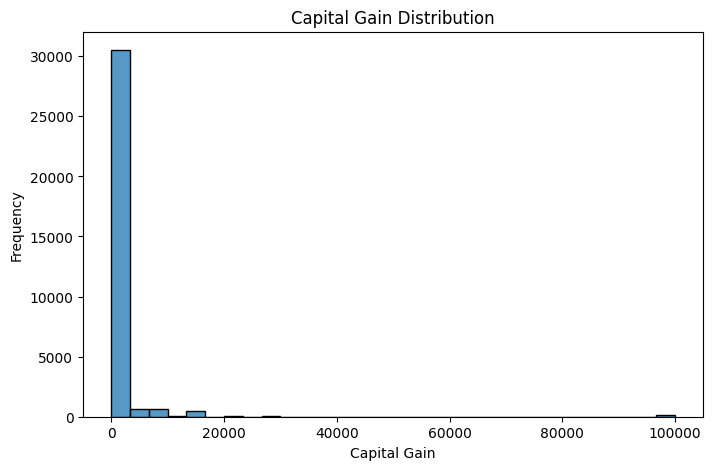

In [132]:
plt.figure(figsize=(8,5))
sns.histplot(
    adult_data['capital_gain'],
    bins=30
)
plt.title('Capital Gain Distribution')
plt.xlabel('Capital Gain')
plt.ylabel('Frequency')
plt.show()

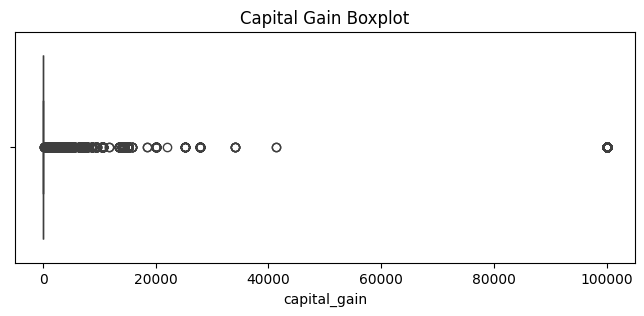

In [133]:
plt.figure(figsize=(8,3))
sns.boxplot(
    x=adult_data['capital_gain']
)
plt.title('Capital Gain Boxplot')
plt.show()

### Capital Loss Insights

- The capital_loss feature exhibits a highly right-skewed distribution.
- More than 75% of individuals report a capital loss value of zero.
- Only a small proportion of individuals incur capital losses, resulting in a concentration of observations near zero.
- The mean capital loss is substantially higher than the median due to the presence of a small number of high-value observations.
- Several statistical outliers are visible in the boxplot; however, these represent legitimate observations rather than errors.
- Capital loss may provide useful predictive information because financial losses are associated with specific economic and investment activities.

In [134]:
adult_data['capital_loss'].describe()

,capital_loss
count,32561.000000
mean,87.303830
std,402.960219
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,4356.000000


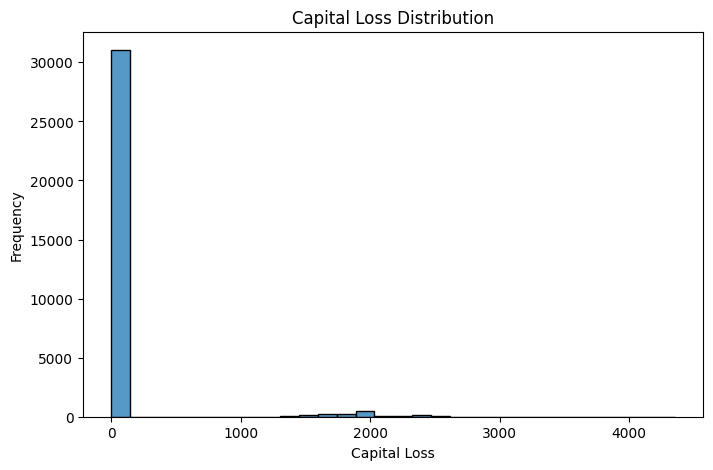

In [135]:
plt.figure(figsize=(8,5))
sns.histplot(
    adult_data['capital_loss'],
    bins=30
)
plt.title('Capital Loss Distribution')
plt.xlabel('Capital Loss')
plt.ylabel('Frequency')
plt.show()

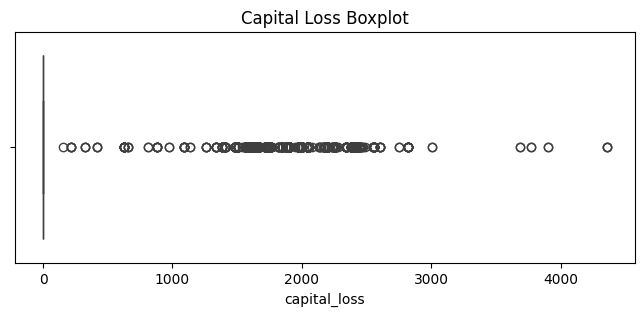

In [136]:
plt.figure(figsize=(8,3))
sns.boxplot(
    x=adult_data['capital_loss']
)
plt.title('Capital Loss Boxplot')
plt.show()

### fnlwgt Insights

- The fnlwgt (Final Weight) feature represents the sampling weight assigned to each individual by the U.S. Census Bureau.
- The distribution is moderately right-skewed, with most observations concentrated between approximately 100,000 and 250,000.
- The median value is approximately 178,356, while the mean is approximately 189,778.
- Several high-value observations appear as statistical outliers in the boxplot; however, these values represent valid census sampling weights.
- Since fnlwgt is a weighting variable rather than a direct demographic characteristic, its predictive value for income will be evaluated during the modeling stage.

In [137]:
adult_data['fnlwgt'].describe()

,fnlwgt
count,3.256100e+04
mean,1.897784e+05
std,1.055500e+05
min,1.228500e+04
25%,1.178270e+05
50%,1.783560e+05
75%,2.370510e+05
max,1.484705e+06


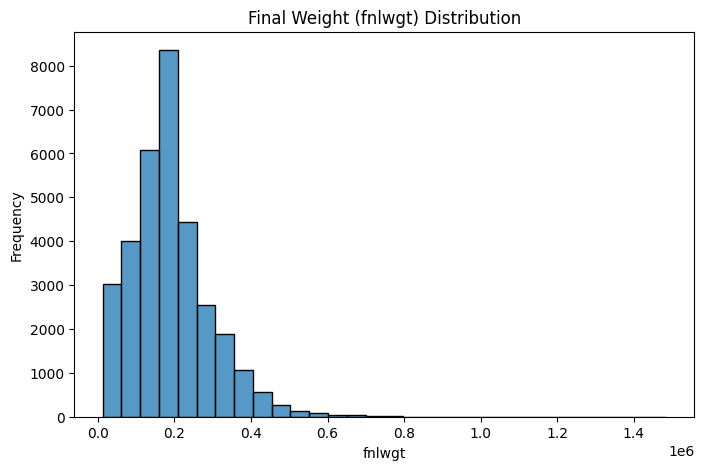

In [138]:
plt.figure(figsize=(8,5))
sns.histplot(
    adult_data['fnlwgt'],
    bins=30
)
plt.title('Final Weight (fnlwgt) Distribution')
plt.xlabel('fnlwgt')
plt.ylabel('Frequency')
plt.show()

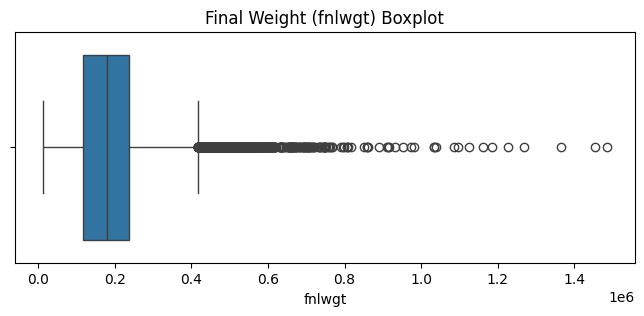

In [139]:
plt.figure(figsize=(8,3))
sns.boxplot(
    x=adult_data['fnlwgt']
)
plt.title('Final Weight (fnlwgt) Boxplot')
plt.show()

# **Categorical Univariate Analysis**

### Workclass Insights

- The majority of individuals in the dataset are employed in the private sector.
- Private employment accounts for the largest proportion of observations, significantly exceeding all other workclass categories.
- Self-employed and government-employed individuals constitute smaller but meaningful portions of the dataset.
- The workclass feature contains a category represented by '?', indicating missing values that will be addressed during preprocessing.
- Categories such as Without-pay and Never-worked are extremely rare and may require special consideration during feature engineering.

In [140]:
adult_data['workclass'].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


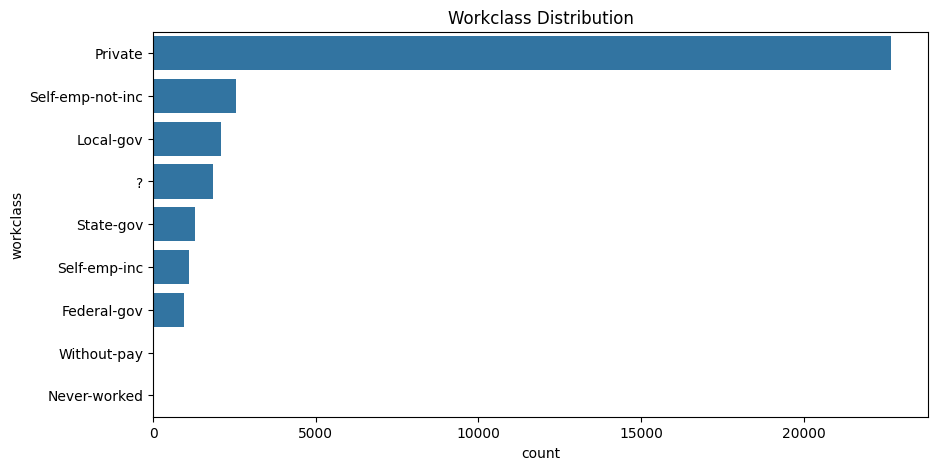

In [141]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=adult_data,
    y='workclass',
    order=adult_data['workclass'].value_counts().index
)

plt.title('Workclass Distribution')

plt.show()

### Occupation Insights

- The dataset contains a diverse set of occupational categories.
- Professional-specialty, craft-repair, executive-managerial, administrative-clerical, and sales occupations are the most frequently represented groups.
- The occupation feature contains missing values represented by the '?' category.
- Some occupations, such as Armed-Forces and Private-house-service, have very low frequencies and may be considered rare categories.
- The diversity of occupations suggests that this feature may provide valuable information for income prediction.

In [142]:
adult_data['occupation'].value_counts()

,count
occupation,
Prof-specialty,4140
Craft-repair,4099
Exec-managerial,4066
Adm-clerical,3770
Sales,3650
Other-service,3295
Machine-op-inspct,2002
?,1843
Transport-moving,1597


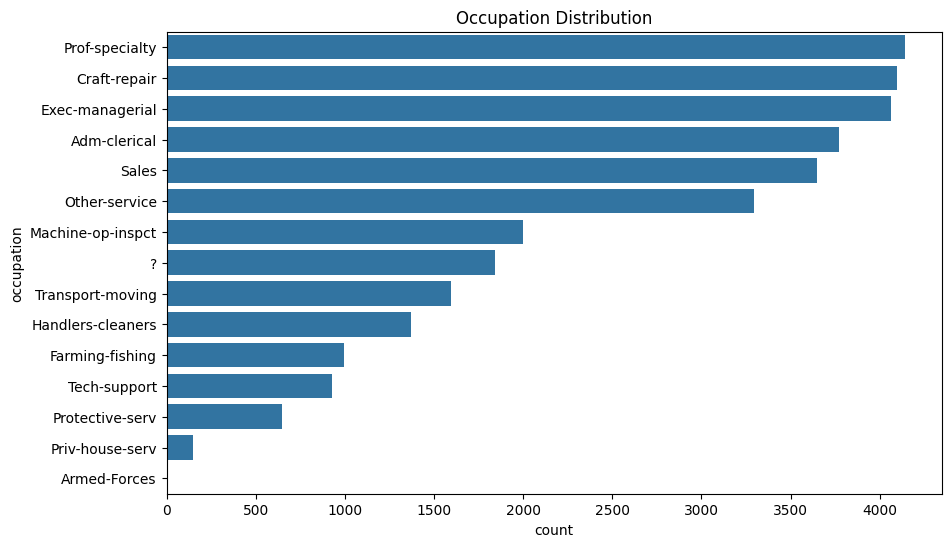

In [143]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=adult_data,
    y='occupation',
    order=adult_data['occupation'].value_counts().index
)

plt.title('Occupation Distribution')

plt.show()

### Education Insights

- High School Graduate (HS-grad) is the most common educational category in the dataset.
- A substantial proportion of individuals have attended some college or obtained a Bachelor's degree.
- Advanced educational qualifications such as Master's, Doctorate, and Professional School degrees are less common.
- Lower education categories such as Preschool and 1st-4th grade contain very few observations.
- The distribution indicates that the majority of individuals possess at least a high school level education.
- Education is expected to play an important role in income prediction due to the variation in educational attainment across individuals.

In [144]:
adult_data['education'].value_counts()

,count
education,
HS-grad,10501
Some-college,7291
Bachelors,5355
Masters,1723
Assoc-voc,1382
11th,1175
Assoc-acdm,1067
10th,933
7th-8th,646


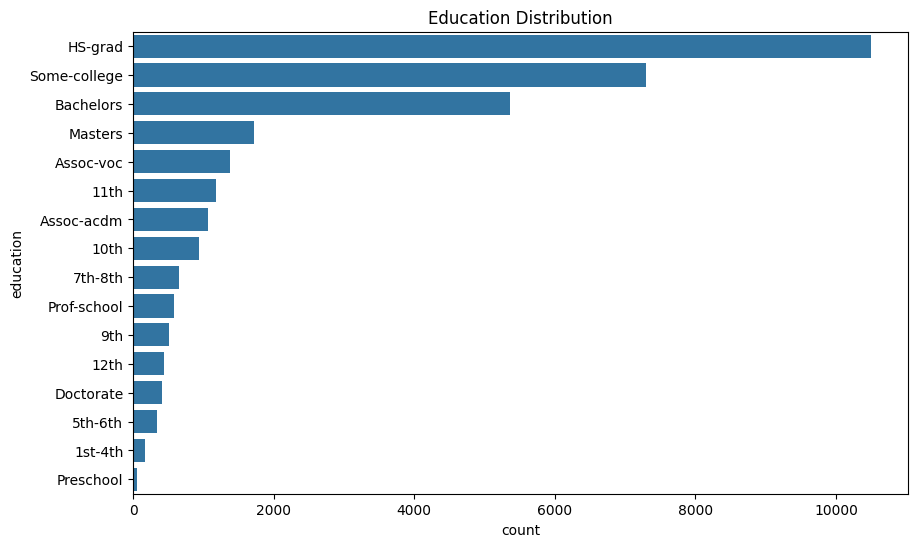

In [145]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=adult_data,
    y='education',
    order=adult_data['education'].value_counts().index
)

plt.title('Education Distribution')

plt.show()

### Marital Status Insights

- Married-civ-spouse is the most common marital status category in the dataset.
- Never-married individuals represent the second largest group, followed by divorced individuals.
- Categories such as separated, widowed, and married-spouse-absent contain substantially fewer observations.
- Married-AF-spouse is a very rare category with only a small number of records.
- The distribution suggests substantial diversity in family and relationship structures across individuals in the dataset.

In [146]:
adult_data['marital_status'].value_counts()

,count
marital_status,
Married-civ-spouse,14976
Never-married,10683
Divorced,4443
Separated,1025
Widowed,993
Married-spouse-absent,418
Married-AF-spouse,23


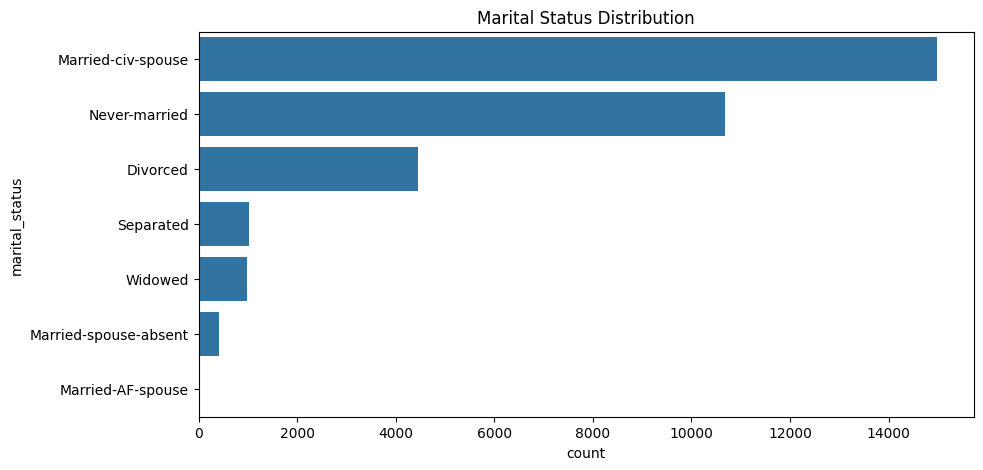

In [147]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=adult_data,
    y='marital_status',
    order=adult_data['marital_status'].value_counts().index
)

plt.title('Marital Status Distribution')

plt.show()

### Relationship Insights

- Husband is the most frequently occurring relationship category in the dataset.
- Not-in-family and Own-child are also highly represented categories.
- The relationship feature captures an individual's role within the household structure.
- Categories such as Unmarried and Other-relative occur less frequently but still represent meaningful portions of the population.
- Household relationship information may provide valuable context for understanding demographic and socioeconomic characteristics.

In [148]:
adult_data['relationship'].value_counts()

,count
relationship,
Husband,13193
Not-in-family,8305
Own-child,5068
Unmarried,3446
Wife,1568
Other-relative,981


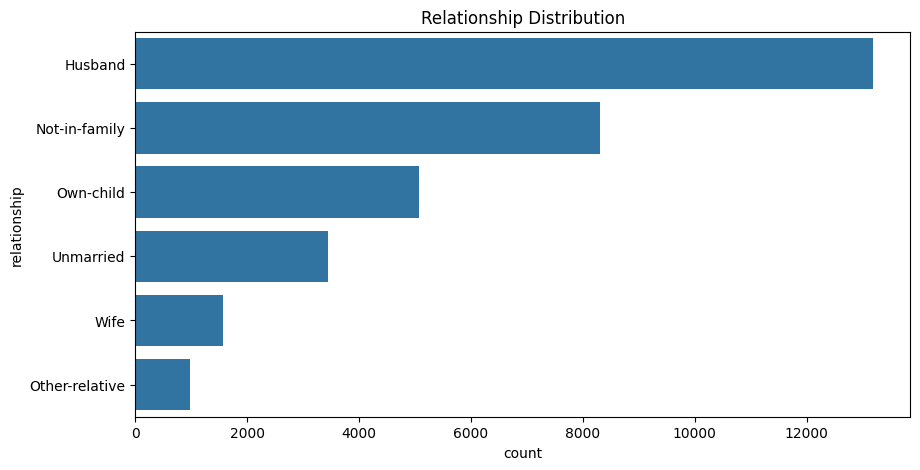

In [149]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=adult_data,
    y='relationship',
    order=adult_data['relationship'].value_counts().index
)
plt.title('Relationship Distribution')
plt.show()

### Race Insights

- White is the dominant racial category in the dataset, accounting for the majority of observations.
- Black and Asian-Pac-Islander represent the second and third largest racial groups, respectively.
- Amer-Indian-Eskimo and Other categories contain relatively few observations.
- The race distribution is highly imbalanced, with a substantial concentration of individuals in the White category.
- This imbalance should be considered when evaluating model performance and fairness across demographic groups.

In [150]:
adult_data['race'].value_counts()

,count
race,
White,27816
Black,3124
Asian-Pac-Islander,1039
Amer-Indian-Eskimo,311
Other,271


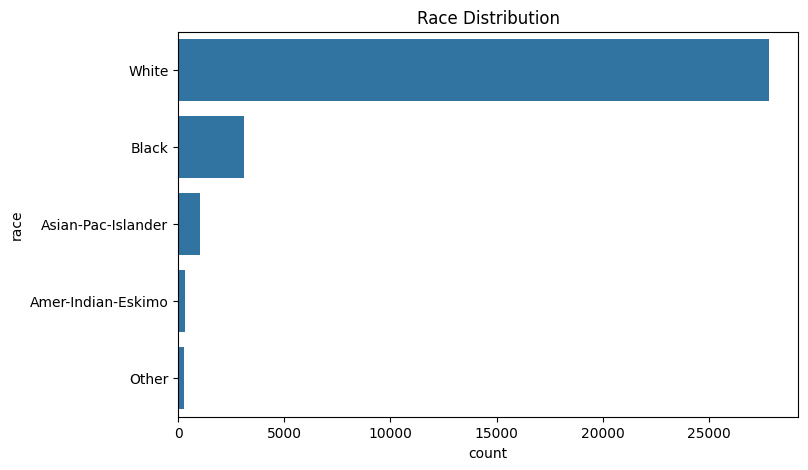

In [151]:
adult_data['race'].value_counts()
plt.figure(figsize=(8,5))
sns.countplot(
    data=adult_data,
    y='race',
    order=adult_data['race'].value_counts().index
)
plt.title('Race Distribution')
plt.show()

### Sex Insights

- The dataset contains substantially more male individuals than female individuals.
- Approximately two-thirds of the observations correspond to males, while one-third correspond to females.
- The distribution indicates a moderate imbalance between sex categories.
- Since income distribution differs across sex groups, this feature will be important for both predictive modeling and fairness evaluation.
- Sex may provide valuable information for understanding demographic patterns within the dataset.

In [152]:
adult_data['sex'].value_counts()

,count
sex,
Male,21790
Female,10771


In [153]:
round(adult_data['sex'].value_counts(normalize=True) * 100, 2)

,proportion
sex,
Male,66.92
Female,33.08


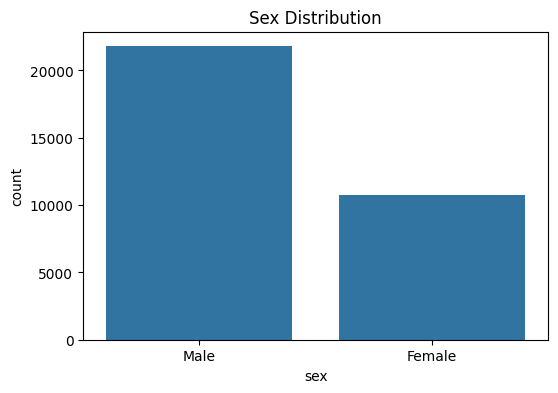

In [154]:
adult_data['sex'].value_counts()

plt.figure(figsize=(6,4))

sns.countplot(
    data=adult_data,
    x='sex'
)

plt.title('Sex Distribution')
plt.show()

# **Bivariate Analysis (Income vs Features)**

### Education vs Income Insights

- Education level exhibits a strong relationship with annual income.
- Individuals with advanced educational qualifications show substantially higher proportions of earning more than $50K.
- Approximately 74.1% of individuals with a Doctorate degree and 73.4% of individuals with a Professional School qualification earn more than $50K.
- More than half of individuals holding a Master's degree earn above $50K.
- In contrast, individuals with lower educational attainment levels such as Preschool, 1st-4th, and 5th-6th grades show very low proportions of high-income earners.
- None of the individuals in the Preschool category earn more than $50K.
- The results suggest that education is one of the strongest predictors of income in the dataset.
- Higher educational attainment is associated with an increased likelihood of belonging to the high-income group.

In [155]:
# income vs Education
education_income = pd.crosstab(
    adult_data['education'],
    adult_data['income'],
    normalize='index') * 100
education_income = education_income.sort_values(by='>50K',ascending=False)
education_income

income,<=50K,>50K
education,,
Doctorate,25.907990,74.092010
Prof-school,26.562500,73.437500
Masters,44.341265,55.658735
Bachelors,58.524743,41.475257
Assoc-voc,73.878437,26.121563
Assoc-acdm,75.164011,24.835989
Some-college,80.976546,19.023454
HS-grad,84.049138,15.950862
12th,92.378753,7.621247


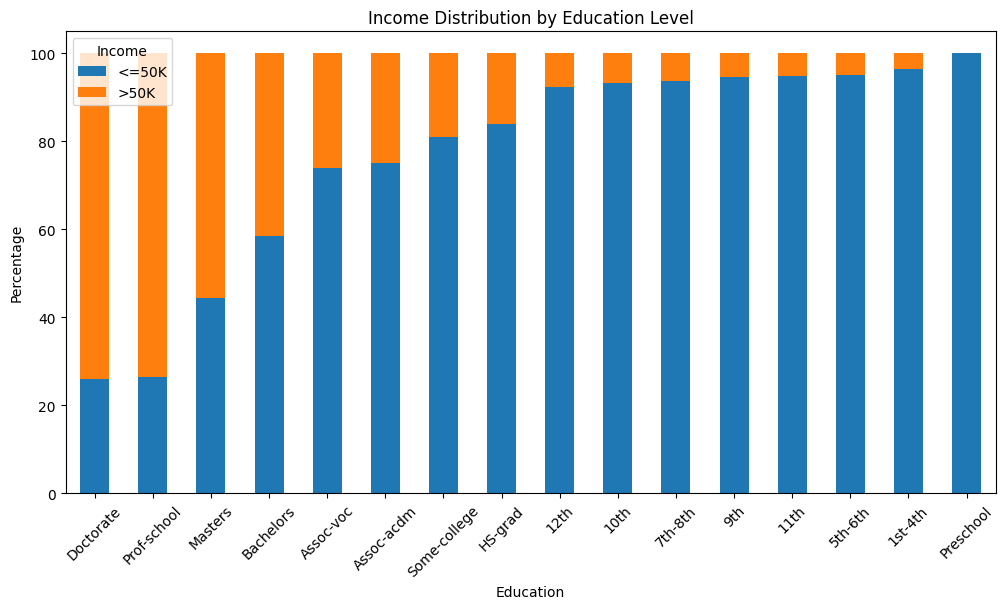

In [156]:
education_income.plot(kind='bar',stacked=True,figsize=(12,6))
plt.title('Income Distribution by Education Level')
plt.xlabel('Education')
plt.ylabel('Percentage')
plt.legend(title='Income')
plt.xticks(rotation=45)
plt.show()

### Hours Worked vs Income Insights

- Individuals earning more than $50K work significantly more hours per week on average.
- The average working time for the >50K group is approximately 45.5 hours per week, compared to 38.8 hours for the <=50K group.
- The median hours worked is also higher for the >50K income group.
- This suggests that working hours may be an important predictor of annual income.

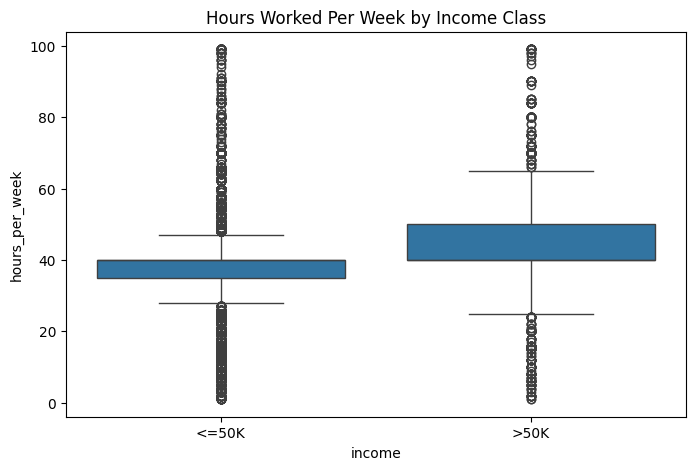

In [157]:
# hours worked vs income
plt.figure(figsize=(8,5))
sns.boxplot(
    data=adult_data,
    x='income',
    y='hours_per_week'
)
plt.title('Hours Worked Per Week by Income Class')
plt.show()

In [158]:
adult_data.groupby('income')['hours_per_week'].mean()

,hours_per_week
income,
<=50K,38.840210
>50K,45.473026


### Age vs Income Insights

- Individuals earning more than 50K tend to be significantly older than individuals earning less than or equal to 50K.
- The average age of the >50K group is approximately 44 years, compared to 37 years for the <=50K group.
- This suggests that work experience and career progression may play an important role in achieving higher income levels.
- Age appears to be a strong predictor of income in this dataset.

In [159]:
# age vs income
adult_data.groupby('income')['age'].mean()

,age
income,
<=50K,36.783738
>50K,44.249841


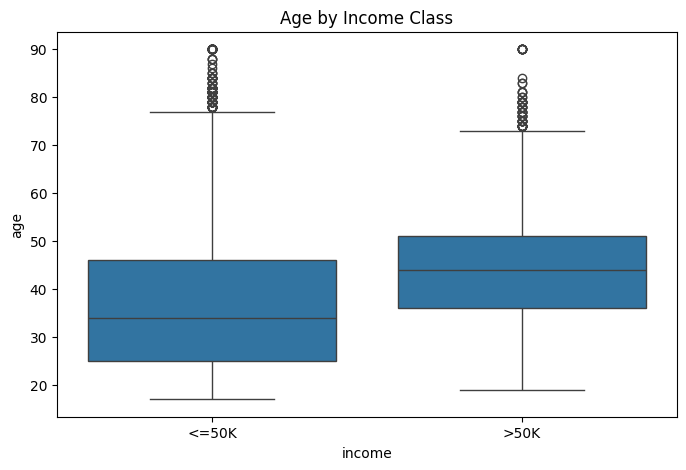

In [160]:
# age vs income
plt.figure(figsize=(8,5))
sns.boxplot(
    data=adult_data,
    x='income',
    y='age'
)
plt.title('Age by Income Class')
plt.show()

### Occupation vs Income Insights

- Occupation exhibits a strong relationship with income level.
- Executive-managerial and professional-specialty occupations show the highest proportions of individuals earning more than $50K.
- Service-oriented occupations such as private-house-service and other-service show very low proportions of high-income earners.
- The probability of earning more than 50K varies substantially across occupational categories, indicating that occupation is likely to be an important predictive feature.



**The occupation category includes records labeled '?' which represent missing values. These will be handled during preprocessing.**

In [161]:
# Occupation vs Income
occupation_income = pd.crosstab(
    adult_data['occupation'],
    adult_data['income'],
    normalize='index'
) * 100
occupation_income = occupation_income.sort_values(
    by='>50K',
    ascending=False
)
occupation_income

income,<=50K,>50K
occupation,,
Exec-managerial,51.598623,48.401377
Prof-specialty,55.096618,44.903382
Protective-serv,67.488444,32.511556
Tech-support,69.504310,30.495690
Sales,73.068493,26.931507
Craft-repair,77.335936,22.664064
Transport-moving,79.962430,20.037570
Adm-clerical,86.551724,13.448276
Machine-op-inspct,87.512488,12.487512


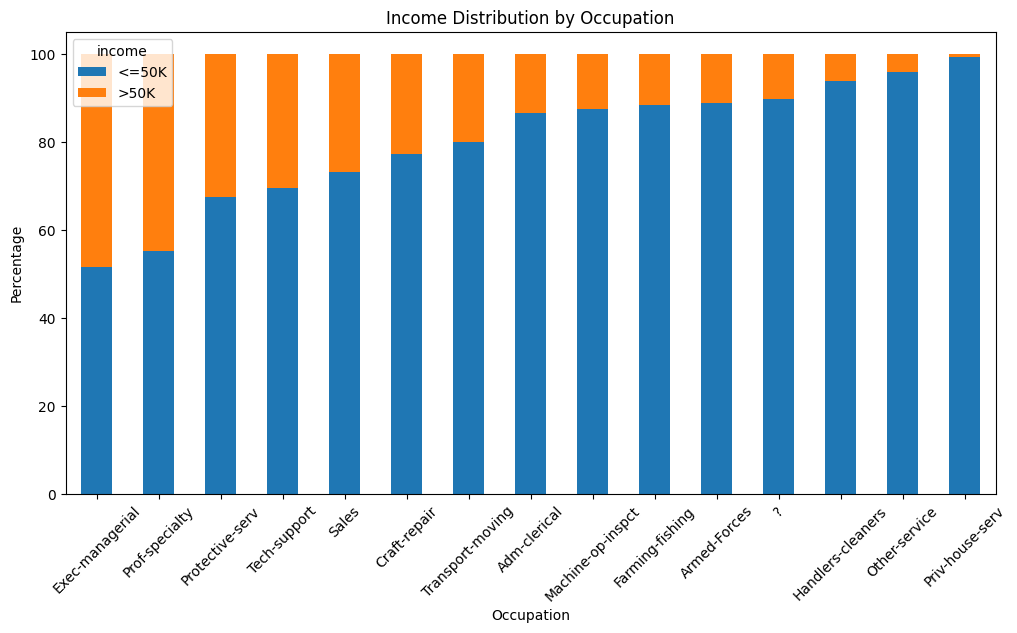

In [162]:
occupation_income.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)
plt.title('Income Distribution by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.show()

### Marital Status vs Income Insights

- Marital status shows a strong association with income level.
- Married individuals have a substantially higher probability of earning more than 50K compared to other marital-status groups.
- Nearly 45% of individuals in the Married-civ-spouse category earn more than 50K.
- In contrast, only about 5% of Never-married individuals earn more than $50K.
- Marital status appears to be one of the strongest categorical predictors of income in the dataset.

In [163]:
# Marital Status vs Income
marital_income = pd.crosstab(
    adult_data['marital_status'],
    adult_data['income'],
    normalize='index'
) * 100
marital_income = marital_income.sort_values(
    by='>50K',
    ascending=False
)
marital_income

income,<=50K,>50K
marital_status,,
Married-civ-spouse,55.315171,44.684829
Married-AF-spouse,56.521739,43.478261
Divorced,89.579113,10.420887
Widowed,91.440081,8.559919
Married-spouse-absent,91.866029,8.133971
Separated,93.560976,6.439024
Never-married,95.403913,4.596087


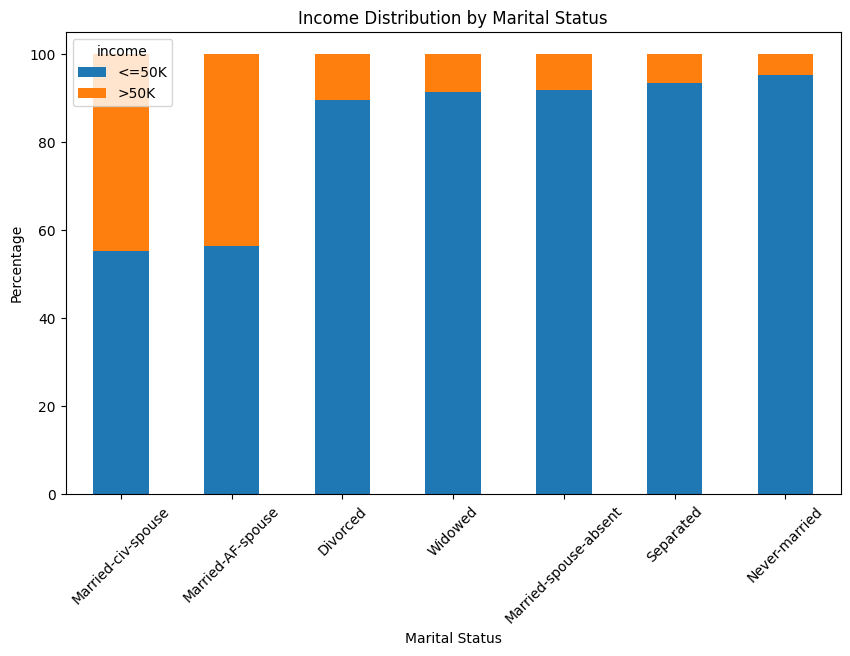

In [164]:
# Marital Status vs Income
marital_income.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)
plt.title('Income Distribution by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.show()

In [165]:
adult_data.groupby('marital_status')['age'].mean().sort_values(ascending=False)

,age
marital_status,
Widowed,58.975831
Married-civ-spouse,43.247596
Divorced,43.041639
Married-spouse-absent,40.578947
Separated,39.354146
Married-AF-spouse,32.478261
Never-married,28.150988


### Sex vs Income Insights

- Income distribution differs substantially across sex categories.
- Approximately 30.6% of males earn more than $50K compared to 10.9% of females.
- The proportion of high-income earners is considerably higher among males in this dataset.
- This feature may have important implications for fairness analysis and responsible AI evaluation.

In [166]:
# Sex vs Income
sex_income = pd.crosstab(
    adult_data['sex'],
    adult_data['income'],
    normalize='index'
) * 100
sex_income = sex_income.sort_values(
    by='>50K',
    ascending=False
)
sex_income

income,<=50K,>50K
sex,,
Male,69.426342,30.573658
Female,89.053941,10.946059


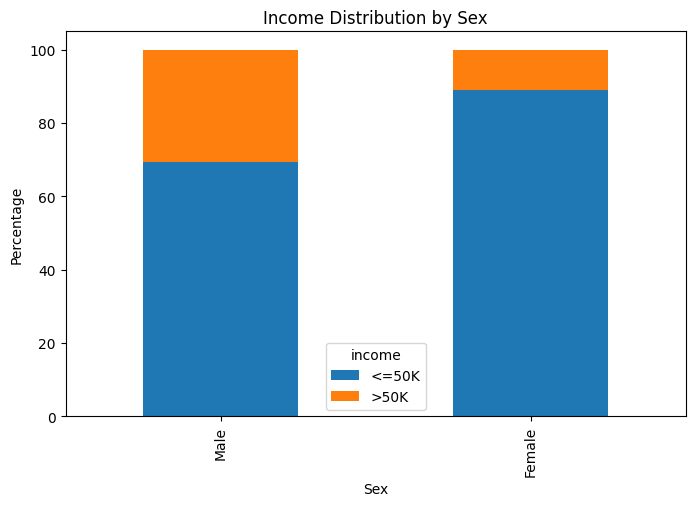

In [167]:
sex_income.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title('Income Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Percentage')
plt.show()

### Race vs Income Insights

- Income distribution varies across racial groups.
- Asian-Pac-Islander and White individuals exhibit the highest proportions of >50K earners.
- Black, Amer-Indian-Eskimo, and Other groups show lower proportions of >50K earners.
- These differences highlight the importance of evaluating fairness metrics across racial groups during model assessment.

In [168]:
# Race vs Income
race_income = pd.crosstab(
    adult_data['race'],
    adult_data['income'],
    normalize='index'
) * 100
race_income = race_income.sort_values(
    by='>50K',
    ascending=False
)
race_income

income,<=50K,>50K
race,,
Asian-Pac-Islander,73.435996,26.564004
White,74.414006,25.585994
Black,87.612036,12.387964
Amer-Indian-Eskimo,88.424437,11.575563
Other,90.774908,9.225092


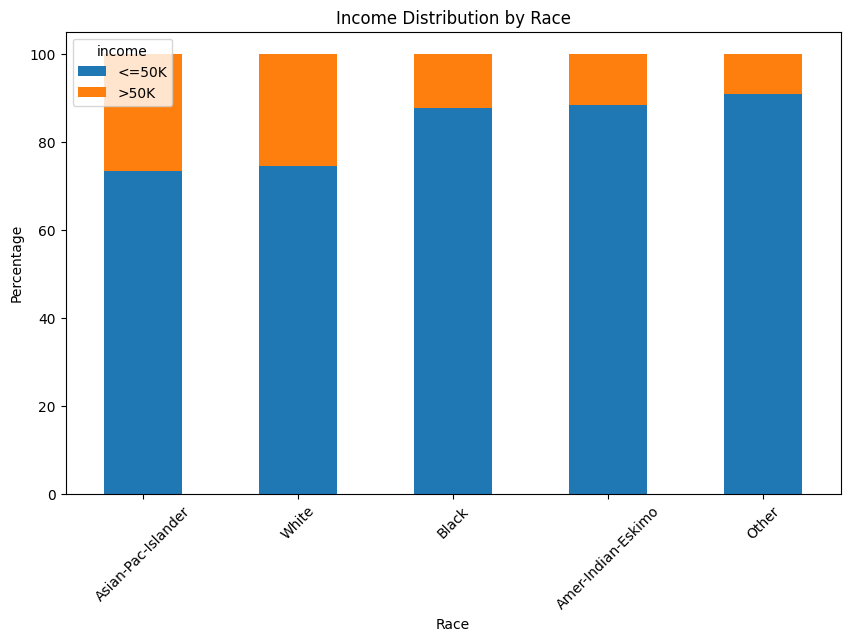

In [169]:
# Race vs Income
race_income.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)
plt.title('Income Distribution by Race')
plt.xlabel('Race')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.show()

# **Correlation Analysis**

- The numerical features exhibit generally weak linear correlations with one another.
- The strongest positive correlation is observed between education_num and hours_per_week (0.15), indicating a slight tendency for individuals with higher education levels to work more hours.
- Education_num also shows a weak positive relationship with capital_gain (0.12).
- Most correlation coefficients are close to zero, suggesting limited linear dependence among numerical variables.
- No evidence of strong multicollinearity is observed in the dataset.
- The low correlation values indicate that each numerical feature may contribute unique information during predictive modeling.

In [170]:
corr_cols = [
    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'capital_loss',
    'hours_per_week'
]
corr_matrix = adult_data[corr_cols].corr()
corr_matrix

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education_num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital_gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital_loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours_per_week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


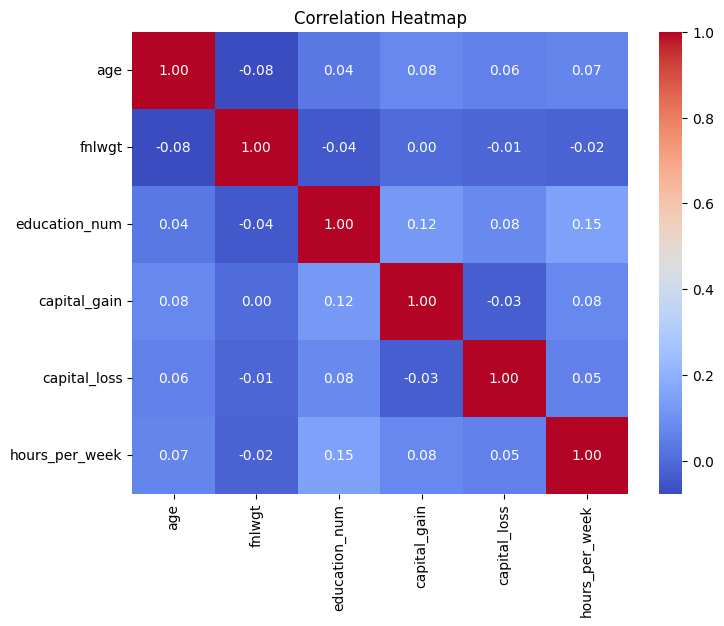

In [171]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

# Key EDA Findings

1. The dataset is moderately imbalanced, with approximately 76% of individuals earning <=50K and 24% earning >50K.

2. Higher education levels are strongly associated with higher income.

3. Individuals earning >50K work approximately 6.6 more hours per week on average.

4. Higher-income individuals are generally older than lower-income individuals.

5. Executive-managerial and professional-specialty occupations have the highest proportions of high-income earners.

6. Married individuals exhibit substantially higher rates of earning more than $50K.

7. Income distribution differs considerably across sex categories.

8. Income distribution varies across racial groups.

9. Capital gain and capital loss are highly skewed features, with most observations concentrated at zero.

10. Education, occupation, age, and hours worked appear to be among the most influential predictors of income.

# EDA Conclusion

The exploratory data analysis identified several demographic, educational, occupational, and work-related characteristics associated with income levels.

Education level, occupation, age, marital status, and hours worked per week demonstrated strong relationships with income and are expected to be important predictive features.

The analysis also revealed class imbalance, skewed financial variables, and demographic disparities across sex and race groups. These findings will guide preprocessing decisions, feature engineering, and model development in subsequent stages of the project.